<a href="https://colab.research.google.com/github/MarcelAzis/Student-Drop-out-Prediction/blob/main/AI_SDG4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SISTEM PREDIKSI STATUS AKADEMIK MAHASISWA

Jenis Machine Learning: Classification

Target Prediksi:
- Dropout
- Enrolled
- Graduate

Algoritma:
1. Logistic Regression
2. Decision Tree
3. Random Forest

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Library berhasil dimuat.")

Library berhasil dimuat.


In [3]:
from google.colab import files

uploaded = files.upload()

Saving Predict_Students_Dropout_and_Academic_Success[1].csv to Predict_Students_Dropout_and_Academic_Success[1].csv


In [4]:
import os

for file in os.listdir():
    print(file)

.config
Predict_Students_Dropout_and_Academic_Success[1].csv
sample_data


In [12]:
df = pd.read_csv("Predict_Students_Dropout_and_Academic_Success[1].csv")

df.columns = df.columns.str.strip()

print("Dataset berhasil dibaca.")
print("Ukuran dataset:", df.shape)

Dataset berhasil dibaca.
Ukuran dataset: (4424, 37)


In [13]:
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [14]:
print("Total data kosong:", df.isnull().sum().sum())

Total data kosong: 0


In [15]:
print("Jumlah baris dobel:", df.duplicated().sum())

Jumlah baris dobel: 0


In [16]:
print(df["Target"].value_counts())

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


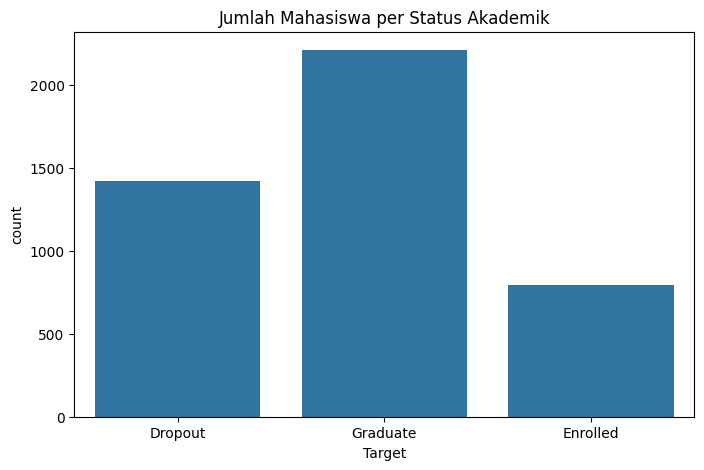

In [17]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Target")
plt.title("Jumlah Mahasiswa per Status Akademik")
plt.show()

In [18]:
df.describe()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


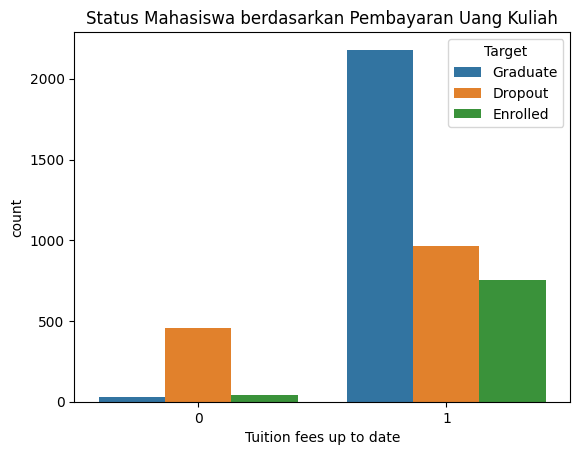

In [19]:
sns.countplot(data=df, x="Tuition fees up to date", hue="Target")
plt.title("Status Mahasiswa berdasarkan Pembayaran Uang Kuliah")
plt.show()

## EDA Tambahan (Tahap 3)
Bagian ini melengkapi EDA: distribusi fitur, hubungan fitur dengan status mahasiswa, dan persentase status berdasarkan faktor finansial.

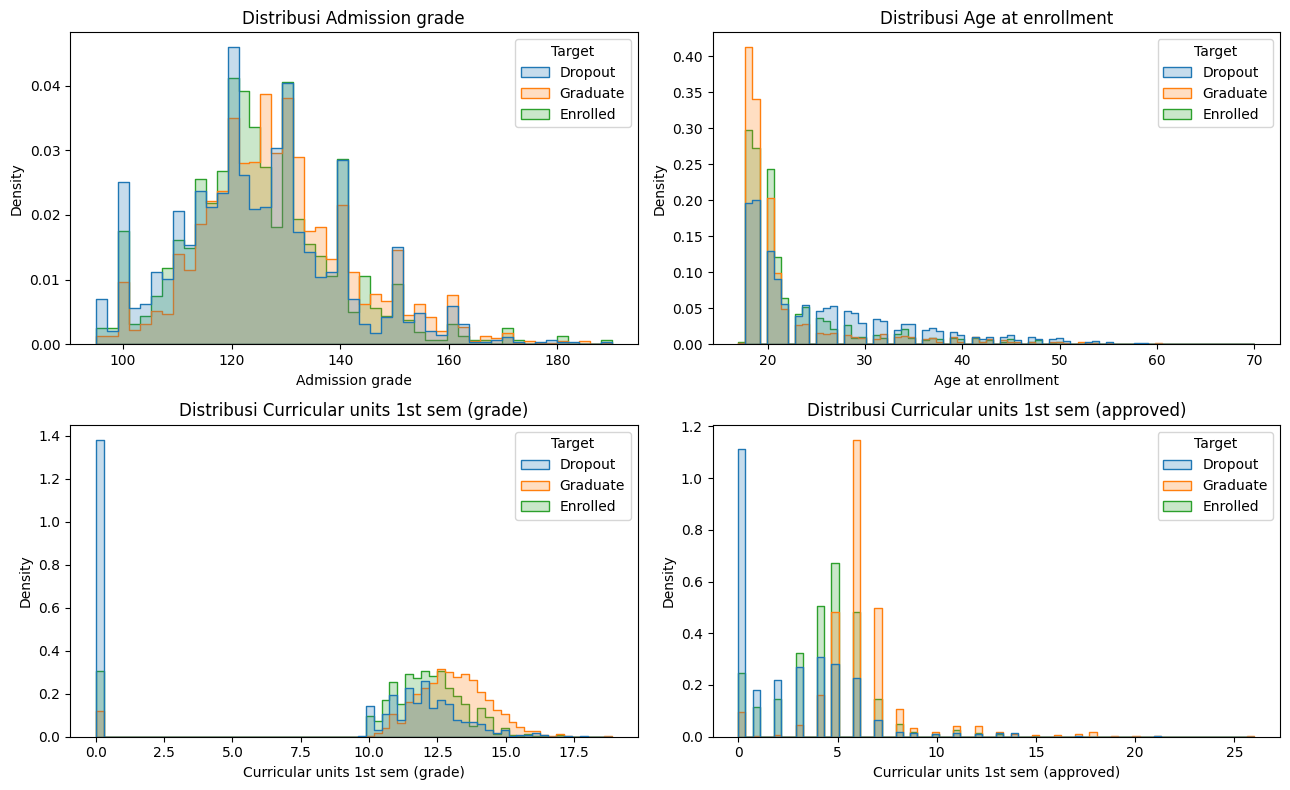

In [20]:
# 1. Distribusi fitur numerik utama per status mahasiswa
fitur_hist = [
    "Admission grade",
    "Age at enrollment",
    "Curricular units 1st sem (grade)",
    "Curricular units 1st sem (approved)",
]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, f in zip(axes.ravel(), fitur_hist):
    sns.histplot(data=df, x=f, hue="Target", element="step",
                 stat="density", common_norm=False, ax=ax)
    ax.set_title(f"Distribusi {f}")
plt.tight_layout()
plt.show()

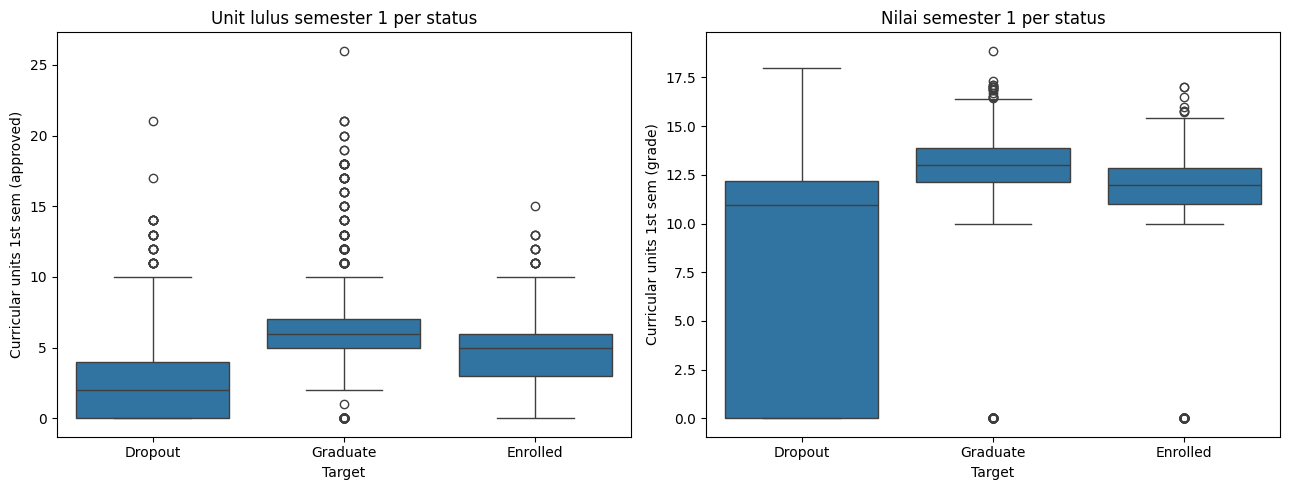

In [21]:
# 2. Boxplot: kinerja semester 1 vs status mahasiswa
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df, x="Target", y="Curricular units 1st sem (approved)", ax=axes[0])
axes[0].set_title("Unit lulus semester 1 per status")

sns.boxplot(data=df, x="Target", y="Curricular units 1st sem (grade)", ax=axes[1])
axes[1].set_title("Nilai semester 1 per status")

plt.tight_layout()
plt.show()

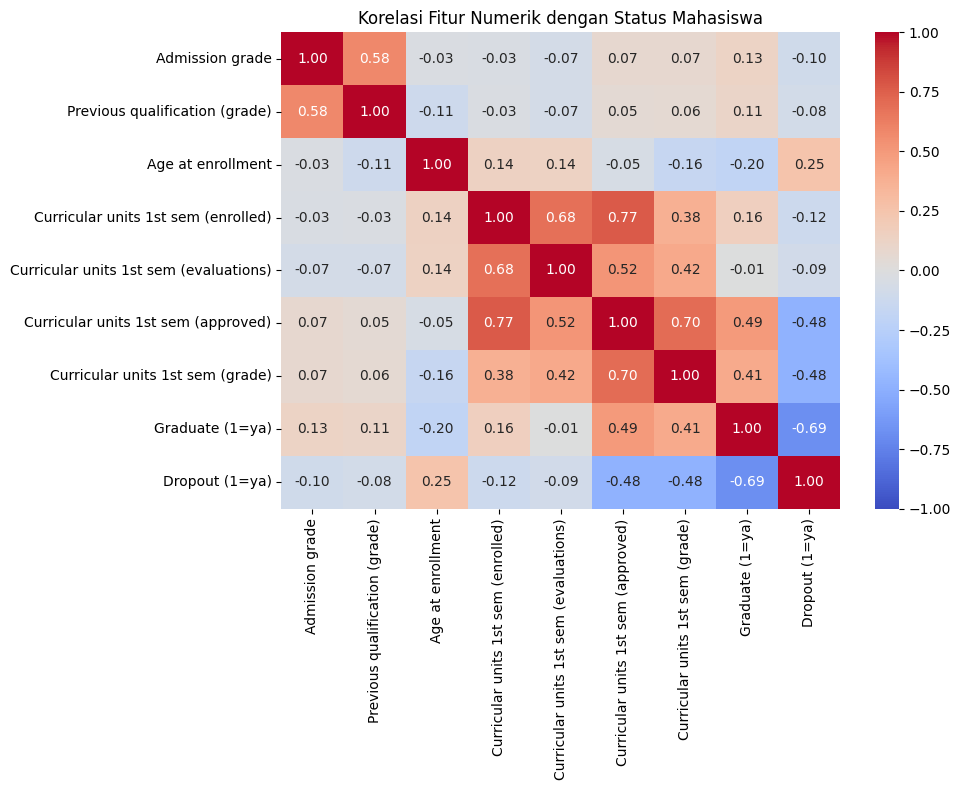

In [22]:
# 3. Heatmap korelasi fitur numerik dengan status (Graduate / Dropout)
fitur_korelasi = [
    "Admission grade",
    "Previous qualification (grade)",
    "Age at enrollment",
    "Curricular units 1st sem (enrolled)",
    "Curricular units 1st sem (evaluations)",
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)",
]

d = df[fitur_korelasi].copy()
d["Graduate (1=ya)"] = (df["Target"] == "Graduate").astype(int)
d["Dropout (1=ya)"] = (df["Target"] == "Dropout").astype(int)

plt.figure(figsize=(10, 8))
sns.heatmap(d.corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Korelasi Fitur Numerik dengan Status Mahasiswa")
plt.tight_layout()
plt.show()

In [23]:
# 4. Persentase status berdasarkan faktor finansial
for kolom in ["Tuition fees up to date", "Debtor", "Scholarship holder"]:
    print(f"=== {kolom} (% per baris) ===")
    print((pd.crosstab(df[kolom], df["Target"], normalize="index") * 100).round(1))
    print()

=== Tuition fees up to date (% per baris) ===
Target                   Dropout  Enrolled  Graduate
Tuition fees up to date                             
0                           86.6       8.0       5.5
1                           24.7      19.3      56.0

=== Debtor (% per baris) ===
Target  Dropout  Enrolled  Graduate
Debtor                             
0          28.3      18.0      53.8
1          62.0      17.9      20.1

=== Scholarship holder (% per baris) ===
Target              Dropout  Enrolled  Graduate
Scholarship holder                             
0                      38.7      20.0      41.3
1                      12.2      11.8      76.0



In [24]:
X = df.drop(columns=["Target"])
y = df["Target"]

print("Ukuran X:", X.shape)
print("Ukuran y:", y.shape)

Ukuran X: (4424, 36)
Ukuran y: (4424,)


In [25]:
kolom_sem2 = [k for k in X.columns if "2nd sem" in k]

print("Kolom yang dibuang:")
for k in kolom_sem2:
    print("-", k)

X = X.drop(columns=kolom_sem2)

print("Jumlah kolom sekarang:", X.shape[1])

Kolom yang dibuang:
- Curricular units 2nd sem (credited)
- Curricular units 2nd sem (enrolled)
- Curricular units 2nd sem (evaluations)
- Curricular units 2nd sem (approved)
- Curricular units 2nd sem (grade)
- Curricular units 2nd sem (without evaluations)
Jumlah kolom sekarang: 30


###  Alasan Pemilihan Fitur (Tahap 4)
Kolom *Curricular units 2nd sem* dibuang karena sistem ini dirancang sebagai **early warning** setelah semester 1. Data semester 2 baru tersedia belakangan dan sangat dekat dengan hasil akhir mahasiswa, sehingga model tampak akurat tetapi tidak berguna untuk peringatan dini (*data leakage*). Tersisa 30 fitur yang sudah diketahui sejak mahasiswa masuk sampai akhir semester 1. Kontribusi tiap fitur dikaji pada bagian *Permutation Importance* di bawah.

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Data belajar (training):", X_train.shape)
print("Data ujian (testing)   :", X_test.shape)

Data belajar (training): (3539, 30)
Data ujian (testing)   : (885, 30)


In [27]:
kolom_kategori = [
    "Marital status", "Application mode", "Application order",
    "Course", "Daytime/evening attendance", "Previous qualification",
    "Nacionality", "Nationality",
    "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation",
    "Displaced", "Educational special needs", "Debtor",
    "Tuition fees up to date", "Gender", "Scholarship holder",
    "International"
]

kolom_kategori = [k for k in kolom_kategori if k in X.columns]

print("Jumlah kolom kategori:", len(kolom_kategori))

Jumlah kolom kategori: 18


In [28]:
kolom_angka = [k for k in X.columns if k not in kolom_kategori]

print("Jumlah kolom angka:", len(kolom_angka))
print(kolom_angka)

Jumlah kolom angka: 12
['Previous qualification (grade)', 'Admission grade', 'Age at enrollment', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP']


In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("angka", StandardScaler(), kolom_angka),
        ("kategori", OneHotEncoder(handle_unknown="ignore"), kolom_kategori)
    ]
)

print("Mesin penerjemah siap.")

Mesin penerjemah siap.


In [30]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model_logistic = Pipeline(steps=[
    ("penerjemah", preprocessor),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

model_logistic.fit(X_train, y_train)

y_pred_logistic = model_logistic.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_logistic))

Accuracy: 0.6983050847457627


In [31]:
from sklearn.tree import DecisionTreeClassifier

model_tree = Pipeline(steps=[
    ("penerjemah", preprocessor),
    ("model", DecisionTreeClassifier(max_depth=10, random_state=42, class_weight="balanced"))
])

model_tree.fit(X_train, y_train)

y_pred_tree = model_tree.predict(X_test)

print("Accuracy Decision Tree:", accuracy_score(y_test, y_pred_tree))

Accuracy Decision Tree: 0.6429378531073446


In [32]:
from sklearn.ensemble import RandomForestClassifier

model_rf = Pipeline(steps=[
    ("penerjemah", preprocessor),
    ("model", RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced", n_jobs=-1))
])

model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

print("Accuracy Random Forest:", accuracy_score(y_test, y_pred_rf))

Accuracy Random Forest: 0.7288135593220338


In [33]:
from sklearn.metrics import f1_score

hasil = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_logistic, average="macro"),
        f1_score(y_test, y_pred_tree, average="macro"),
        f1_score(y_test, y_pred_rf, average="macro")
    ]
})

hasil.round(4)

,Model,Accuracy,F1-Score
0,Logistic Regression,0.6983,0.6574
1,Decision Tree,0.6429,0.5982
2,Random Forest,0.7288,0.6212


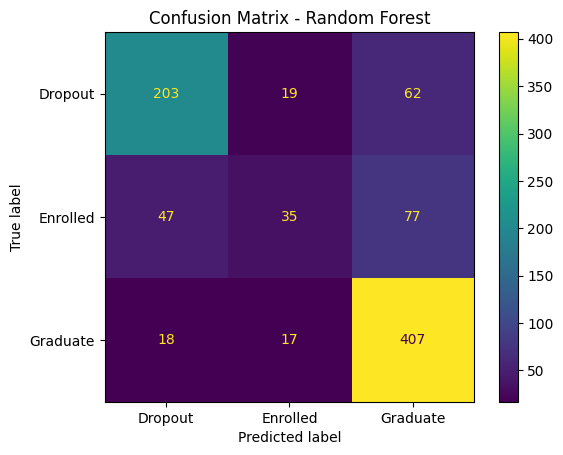

In [34]:
from sklearn.metrics import ConfusionMatrixDisplay

label = ["Dropout", "Enrolled", "Graduate"]

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    labels=label
)

plt.title("Confusion Matrix - Random Forest")
plt.show()

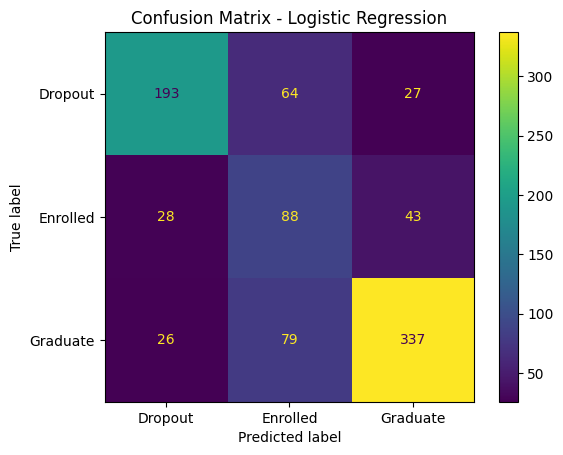

In [35]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_logistic,
    labels=label
)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [36]:
from sklearn.metrics import classification_report

print("=== RANDOM FOREST ===")
print(classification_report(y_test, y_pred_rf))

print("=== LOGISTIC REGRESSION ===")
print(classification_report(y_test, y_pred_logistic))

=== RANDOM FOREST ===
              precision    recall  f1-score   support

     Dropout       0.76      0.71      0.74       284
    Enrolled       0.49      0.22      0.30       159
    Graduate       0.75      0.92      0.82       442

    accuracy                           0.73       885
   macro avg       0.67      0.62      0.62       885
weighted avg       0.70      0.73      0.70       885

=== LOGISTIC REGRESSION ===
              precision    recall  f1-score   support

     Dropout       0.78      0.68      0.73       284
    Enrolled       0.38      0.55      0.45       159
    Graduate       0.83      0.76      0.79       442

    accuracy                           0.70       885
   macro avg       0.66      0.67      0.66       885
weighted avg       0.73      0.70      0.71       885



## Evaluasi Lengkap (Tahap 7)
Melengkapi evaluasi dengan precision, recall, ROC-AUC, kurva ROC, dan cross-validation.

In [37]:
# 1. Tabel perbandingan lengkap (termasuk recall per kelas dan ROC-AUC)
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score)

semua_model = {
    "Logistic Regression": model_logistic,
    "Decision Tree": model_tree,
    "Random Forest": model_rf,
}

baris = []
for nama, m in semua_model.items():
    y_hat = m.predict(X_test)
    proba = m.predict_proba(X_test)
    baris.append({
        "Model": nama,
        "Accuracy": accuracy_score(y_test, y_hat),
        "Precision (macro)": precision_score(y_test, y_hat, average="macro", zero_division=0),
        "Recall (macro)": recall_score(y_test, y_hat, average="macro"),
        "F1 (macro)": f1_score(y_test, y_hat, average="macro"),
        "Recall Dropout": recall_score(y_test, y_hat, labels=["Dropout"], average=None)[0],
        "Recall Enrolled": recall_score(y_test, y_hat, labels=["Enrolled"], average=None)[0],
        "ROC-AUC (OvR)": roc_auc_score(y_test, proba, multi_class="ovr",
                                       average="macro", labels=m.classes_),
    })

tabel_lengkap = pd.DataFrame(baris).set_index("Model").round(4)
tabel_lengkap

,Accuracy,Precision (macro),Recall (macro),F1 (macro),Recall Dropout,Recall Enrolled,ROC-AUC (OvR)
Model,,,,,,,
Logistic Regression,0.6983,0.6634,0.6652,0.6574,0.6796,0.5535,0.8545
Decision Tree,0.6429,0.6094,0.6048,0.5982,0.5845,0.4969,0.7344
Random Forest,0.7288,0.6653,0.6186,0.6212,0.7148,0.2201,0.8586


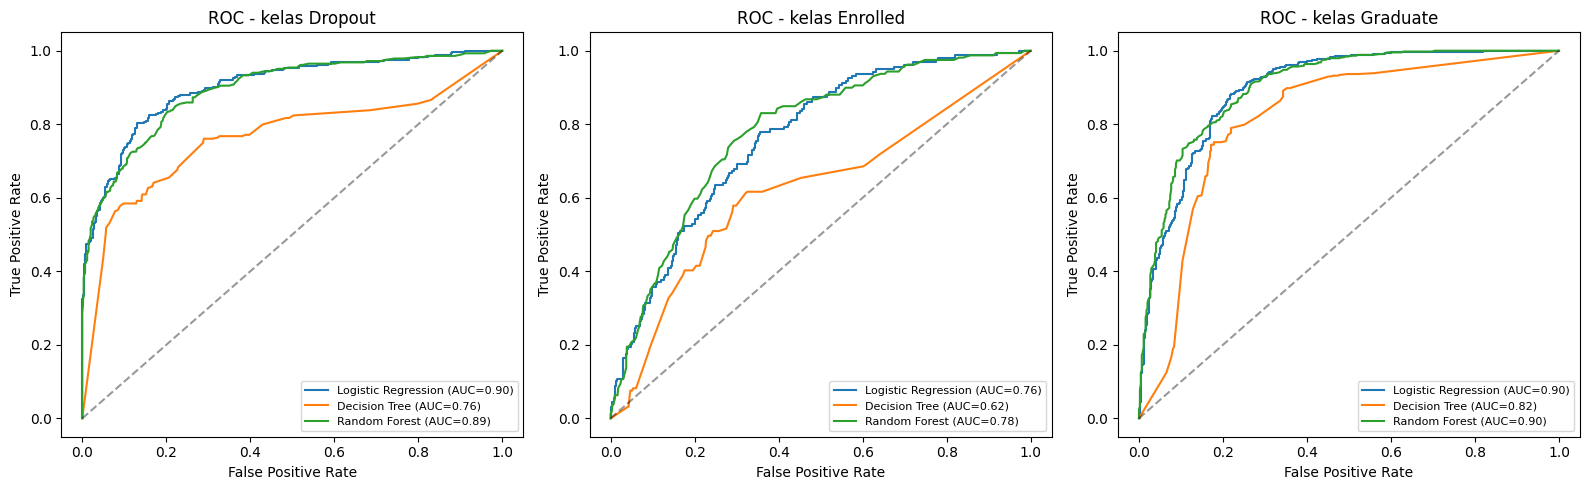

In [38]:
# 2. Kurva ROC (one-vs-rest) untuk tiap kelas
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

kelas = ["Dropout", "Enrolled", "Graduate"]
y_bin = label_binarize(y_test, classes=kelas)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, k in enumerate(kelas):
    for nama, m in semua_model.items():
        skor = m.predict_proba(X_test)[:, list(m.classes_).index(k)]
        fpr, tpr, _ = roc_curve(y_bin[:, i], skor)
        axes[i].plot(fpr, tpr, label=f"{nama} (AUC={auc(fpr, tpr):.2f})")
    axes[i].plot([0, 1], [0, 1], "k--", alpha=0.4)
    axes[i].set_title(f"ROC - kelas {k}")
    axes[i].set_xlabel("False Positive Rate")
    axes[i].set_ylabel("True Positive Rate")
    axes[i].legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

In [39]:
# [TAMBAHAN] 3. Stratified 5-fold cross-validation (seluruh data)
# Preprocessing ada di dalam pipeline, jadi tiap fold di-fit ulang tanpa kebocoran data.
from sklearn.model_selection import StratifiedKFold, cross_validate

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
metrik = {"accuracy": "accuracy", "f1_macro": "f1_macro", "roc_auc": "roc_auc_ovr"}

hasil_cv = []
for nama, m in semua_model.items():
    cv = cross_validate(m, X, y, cv=skf, scoring=metrik)
    hasil_cv.append({
        "Model": nama,
        "Accuracy (rata-rata)": cv["test_accuracy"].mean(),
        "Accuracy (std)": cv["test_accuracy"].std(),
        "F1 macro (rata-rata)": cv["test_f1_macro"].mean(),
        "F1 macro (std)": cv["test_f1_macro"].std(),
        "ROC-AUC (rata-rata)": cv["test_roc_auc"].mean(),
    })

pd.DataFrame(hasil_cv).set_index("Model").round(4)

,Accuracy (rata-rata),Accuracy (std),F1 macro (rata-rata),F1 macro (std),ROC-AUC (rata-rata)
Model,,,,,
Logistic Regression,0.7159,0.0157,0.6734,0.0137,0.8618
Decision Tree,0.6576,0.0076,0.6210,0.0102,0.7622
Random Forest,0.7380,0.0041,0.6265,0.0076,0.8625


In [40]:
nama_fitur = model_rf.named_steps["penerjemah"].get_feature_names_out()
pentingnya = model_rf.named_steps["model"].feature_importances_

tabel_fitur = pd.DataFrame({
    "Fitur": nama_fitur,
    "Penting": pentingnya
})

tabel_fitur = tabel_fitur.sort_values("Penting", ascending=False)

tabel_fitur.head(10)

,Fitur,Penting
6,angka__Curricular units 1st sem (approved),0.091469
7,angka__Curricular units 1st sem (grade),0.081159
5,angka__Curricular units 1st sem (evaluations),0.052262
1,angka__Admission grade,0.046396
0,angka__Previous qualification (grade),0.042069
2,angka__Age at enrollment,0.040860
11,angka__GDP,0.029244
238,kategori__Tuition fees up to date_1,0.028405
9,angka__Unemployment rate,0.028393
10,angka__Inflation rate,0.025681


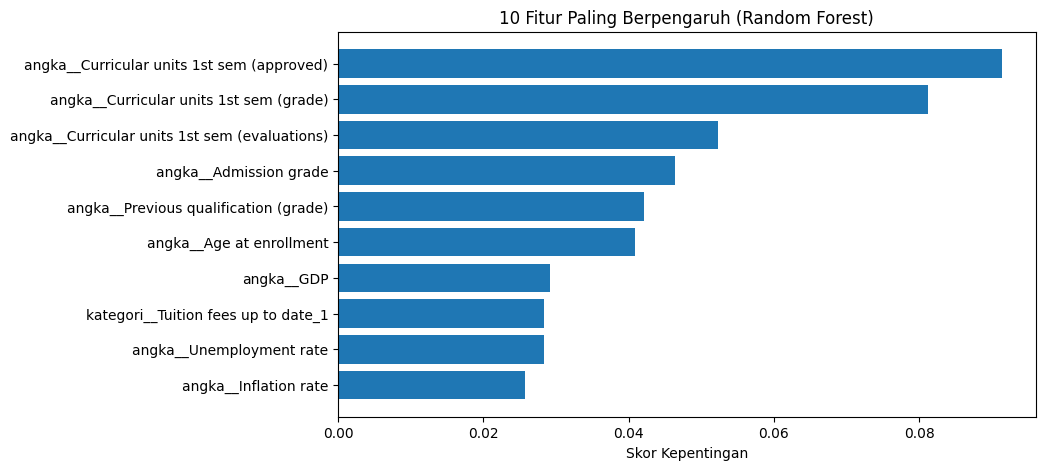

In [41]:
top = tabel_fitur.head(10)

plt.figure(figsize=(9, 5))
plt.barh(top["Fitur"][::-1], top["Penting"][::-1])
plt.title("10 Fitur Paling Berpengaruh (Random Forest)")
plt.xlabel("Skor Kepentingan")
plt.show()

###  Permutation Importance
*Feature importance* Random Forest di atas dihitung per kolom hasil one-hot, sehingga fitur kategori terlihat kecil karena skornya terpecah. *Permutation importance* bekerja pada kolom asli dan mengukur seberapa turun F1 saat satu fitur diacak.

=== Logistic Regression ===
                                 Fitur  Penurunan F1    Std
   Curricular units 1st sem (approved)        0.2159 0.0136
               Tuition fees up to date        0.0509 0.0044
      Curricular units 1st sem (grade)        0.0391 0.0023
   Curricular units 1st sem (enrolled)        0.0354 0.0090
Curricular units 1st sem (evaluations)        0.0269 0.0087
                                Course        0.0187 0.0076
   Curricular units 1st sem (credited)        0.0130 0.0034
                                Gender        0.0118 0.0045
                   Father's occupation        0.0105 0.0056
                     Age at enrollment        0.0086 0.0045

=== Random Forest ===
                                 Fitur  Penurunan F1    Std
   Curricular units 1st sem (approved)        0.0893 0.0039
               Tuition fees up to date        0.0538 0.0075
Curricular units 1st sem (evaluations)        0.0347 0.0098
      Curricular units 1st sem (grade)        0.0

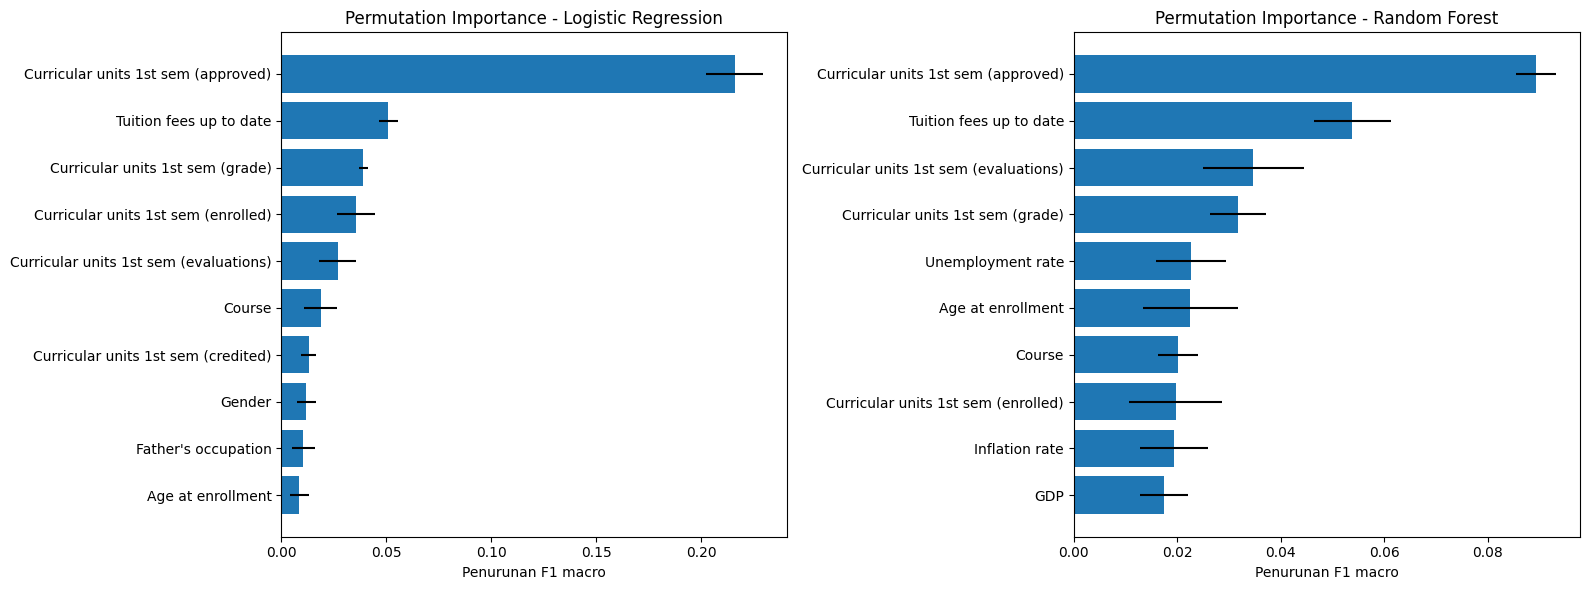

In [42]:
# Permutation importance pada kolom asli (model final dan pembanding)
from sklearn.inspection import permutation_importance

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (nama, m) in zip(axes, [("Logistic Regression", model_logistic),
                                ("Random Forest", model_rf)]):
    perm = permutation_importance(m, X_test, y_test, scoring="f1_macro",
                                  n_repeats=5, random_state=42, n_jobs=-1)
    tabel_perm = (pd.DataFrame({"Fitur": X_test.columns,
                                "Penurunan F1": perm.importances_mean,
                                "Std": perm.importances_std})
                  .sort_values("Penurunan F1", ascending=False)
                  .head(10))
    print(f"=== {nama} ===")
    print(tabel_perm.round(4).to_string(index=False))
    print()
    ax.barh(tabel_perm["Fitur"][::-1], tabel_perm["Penurunan F1"][::-1],
            xerr=tabel_perm["Std"][::-1])
    ax.set_title(f"Permutation Importance - {nama}")
    ax.set_xlabel("Penurunan F1 macro")

plt.tight_layout()
plt.show()

In [43]:
import joblib

joblib.dump(model_logistic, "model_status_mahasiswa.pkl")

print("Model berhasil disimpan.")

Model berhasil disimpan.


In [44]:
mahasiswa = X_test.iloc[[0]]

prediksi = model_logistic.predict(mahasiswa)[0]
probabilitas = model_logistic.predict_proba(mahasiswa)[0]

print("Tebakan AI  :", prediksi)
print("Jawaban asli:", y_test.iloc[0])
print()
print("Peluang tiap status:")
for kelas, p in zip(model_logistic.classes_, probabilitas):
    print(f"{kelas}: {p*100:.1f}%")

Tebakan AI  : Graduate
Jawaban asli: Graduate

Peluang tiap status:
Dropout: 5.6%
Enrolled: 28.7%
Graduate: 65.7%


In [46]:
import random
nomor = random.randint(0, len(X_test) - 1)

mahasiswa = X_test.iloc[[nomor]]
prediksi = model_logistic.predict(mahasiswa)[0]

print("Mahasiswa nomor : ", nomor)
print("Tebakan AI      : ", prediksi)
print("Jawaban asli    : ", y_test.iloc[nomor])
print()

if prediksi == "Dropout":
    print("⚠️ EARLY WARNING")
    print("Model memprediksi mahasiswa ini berisiko Dropout.")
    print("Pertimbangkan pendampingan akademik.")
elif prediksi == "Enrolled":
    print("STATUS: ENROLLED")
    print("Model memprediksi mahasiswa masih berstatus Enrolled.")
else:
    print("STATUS: GRADUATE")
    print("Model memprediksi mahasiswa akan lulus.")

Mahasiswa nomor :  626
Tebakan AI      :  Enrolled
Jawaban asli    :  Enrolled

STATUS: ENROLLED
Model memprediksi mahasiswa masih berstatus Enrolled.


###  Prediksi Lebih Menyeluruh (Tahap 8)
Contoh acak satu mahasiswa belum cukup untuk menilai model. Berikut 10 sampel dengan seed tetap (bisa diulang) dan daftar 20 mahasiswa dengan risiko Dropout tertinggi.

In [47]:
# 1. Sepuluh sampel reproducible
rng = np.random.default_rng(42)
idx = rng.choice(len(X_test), size=10, replace=False)
sampel = X_test.iloc[idx]

kls = list(model_logistic.classes_)
p_sampel = model_logistic.predict_proba(sampel)

tabel_sampel = pd.DataFrame({
    "No (X_test)": idx,
    "Aktual": y_test.iloc[idx].values,
    "Prediksi": model_logistic.predict(sampel),
    "P(Dropout) %": (p_sampel[:, kls.index("Dropout")] * 100).round(1),
})
tabel_sampel["Benar?"] = np.where(tabel_sampel["Aktual"] == tabel_sampel["Prediksi"], "Ya", "Tidak")

display(tabel_sampel)
print("Prediksi benar:", (tabel_sampel["Benar?"] == "Ya").sum(), "dari 10")

,No (X_test),Aktual,Prediksi,P(Dropout) %,Benar?
0,75,Graduate,Graduate,7.3,Ya
1,678,Dropout,Graduate,4.0,Tidak
2,78,Dropout,Dropout,40.1,Ya
3,574,Enrolled,Enrolled,25.9,Ya
4,385,Enrolled,Enrolled,15.3,Ya
5,381,Graduate,Graduate,10.5,Ya
6,615,Dropout,Dropout,98.6,Ya
7,83,Graduate,Enrolled,0.9,Tidak
8,178,Dropout,Dropout,98.2,Ya
9,756,Graduate,Graduate,6.6,Ya


Prediksi benar: 8 dari 10


In [48]:
# 2. Daftar early warning: 20 mahasiswa dengan peluang Dropout tertinggi
p_dropout = model_logistic.predict_proba(X_test)[:, kls.index("Dropout")]
top20 = np.argsort(p_dropout)[::-1][:20]

aktual_top20 = y_test.iloc[top20].values
print("Dari 20 mahasiswa berisiko tertinggi menurut model:")
print("- Benar-benar Dropout :", (aktual_top20 == "Dropout").sum())
print("- Enrolled            :", (aktual_top20 == "Enrolled").sum())
print("- Graduate            :", (aktual_top20 == "Graduate").sum())
print()
print("Ketepatan peringatan dini (precision@20):",
      f"{(aktual_top20 == 'Dropout').mean() * 100:.0f}%")

Dari 20 mahasiswa berisiko tertinggi menurut model:
- Benar-benar Dropout : 20
- Enrolled            : 0
- Graduate            : 0

Ketepatan peringatan dini (precision@20): 100%


## Kesimpulan

Proyek ini membuat sistem klasifikasi status akademik mahasiswa
(Dropout, Enrolled, Graduate) untuk mendukung SDG 4 sebagai
Early Warning System.

1. Tiga model dibandingkan: Logistic Regression, Decision Tree,
   dan Random Forest.
2. Random Forest memiliki accuracy tertinggi (0.7288), tetapi
   Logistic Regression memiliki F1-Score tertinggi (0.6574).
3. Kelas Enrolled paling sulit diprediksi. Recall Random Forest
   pada kelas ini hanya 0.22, sedangkan Logistic Regression 0.55.
4. Karena itu evaluasi tidak hanya memakai accuracy, tetapi juga
   F1-Score dan confusion matrix.
5. Fitur akademik semester 1 (unit lulus, nilai, evaluasi)
   berkontribusi terbesar terhadap prediksi model.
6. Logistic Regression dipilih sebagai model final dan disimpan
   dalam file model_status_mahasiswa.pkl.

Sistem ini bukan pengambil keputusan final, melainkan alat bantu
untuk mengidentifikasi mahasiswa yang mungkin memerlukan
pendampingan akademik.

## Rekomendasi untuk Pihak Akademik (Tahap 9)

1. **Pantau mahasiswa setelah semester 1.** Unit lulus dan nilai semester 1 adalah fitur yang paling berpengaruh, jadi mahasiswa dengan unit lulus dan nilai rendah perlu didampingi dosen wali lebih awal.
2. **Perhatikan faktor finansial.** Status pembayaran uang kuliah ikut berpengaruh pada prediksi, sehingga informasi keringanan biaya atau beasiswa perlu disampaikan lebih awal.
3. **Gunakan model sebagai screening, bukan vonis.** Daftar peringatan dini diverifikasi manusia sebelum ada tindakan.
4. **Waspadai kelompok Enrolled.** Kelas ini paling sulit diprediksi (recall rendah), jadi pemantauannya tidak boleh bergantung pada model saja.
5. **Lindungi data mahasiswa.** Gunakan data anonim bila memungkinkan, batasi akses, dan pastikan ada dasar persetujuan sesuai UU No. 27 Tahun 2022 tentang Pelindungan Data Pribadi.
6. **Evaluasi dan latih ulang secara berkala** karena kondisi mahasiswa dan kebijakan kampus berubah.

## Jawaban Pertanyaan Analisis

1. **Faktor paling berpengaruh:** kinerja akademik semester 1 (unit lulus, nilai, evaluasi), disusul status uang kuliah dan nilai masuk. Cek tabel *Permutation Importance* untuk urutan pastinya.
2. **Model terbaik:** Random Forest unggul di accuracy (0,7288), tetapi Logistic Regression unggul di F1 macro (0,6574) dan recall kelas Enrolled. Model final dipilih berdasarkan F1 macro karena kelas tidak seimbang.
3. **Apakah accuracy cukup?** Tidak. Kelas tidak seimbang dan accuracy menyembunyikan kegagalan pada kelas Enrolled (recall RF hanya 0,22). Karena itu dipakai F1, recall per kelas, ROC-AUC, dan confusion matrix.
4. **Risiko jika mahasiswa berisiko diprediksi aman (false negative):** mahasiswa yang akan Dropout tidak mendapat pendampingan sehingga tujuan early warning gagal. Karena itu recall kelas Dropout harus dipantau.
5. **Apakah data boleh dipakai sembarangan?** Tidak. Data mahasiswa adalah data pribadi, perlu tujuan yang jelas, persetujuan, dan akses terbatas.
6. **Privasi dan keamanan:** anonimisasi (hapus identitas langsung), enkripsi penyimpanan, kontrol akses, dan hanya memakai fitur yang diperlukan.
7. **Rekomendasi ke akademik:** lihat daftar rekomendasi di atas.

## Refleksi

1. **Dampak positif AI di kampus:** mendeteksi mahasiswa berisiko lebih awal, mengarahkan pendampingan secara tepat sasaran, dan membantu kampus memakai sumber daya bimbingan lebih efisien.
2. **Tantangan terbesar:** kualitas dan bias data, perlindungan privasi, risiko label yang menstigma mahasiswa, dan memastikan keputusan akhir tetap dipegang manusia.